# Data

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd

from src import config as c, data, netback, sql

pd.set_option("display.float_format", "{:,.3f}".format)
plt.rcParams.update({"figure.figsize": (10, 3), "axes.grid": True, "grid.alpha": .3})

In [2]:
tokyo = data.dataset("tokyo")
rotterdam = data.dataset("rotterdam")

In [3]:
tokyo.shape, rotterdam.shape

((257, 10), (242, 13))

In [4]:
tokyo.head()

,asof_utc,dest_contract,dest_trade_date,dest_settle,dest_settle_utc,freight_contract,freight_trade_date,freight_settle,freight_settle_utc,staleness_days
trade_date,,,,,,,,,,
2025-01-02,2025-01-02 22:00:00+00:00,JKMH2025,2025-01-02,15.055,2025-01-02 08:30:00+00:00,BLNG3G2025,2025-01-02,"61,333.000",2025-01-02 16:00:00+00:00,0
2025-01-03,2025-01-03 22:00:00+00:00,JKMH2025,2025-01-03,14.945,2025-01-03 08:30:00+00:00,BLNG3G2025,2025-01-03,"61,333.000",2025-01-03 16:00:00+00:00,0
2025-01-06,2025-01-06 22:00:00+00:00,JKMH2025,2025-01-06,14.605,2025-01-06 08:30:00+00:00,BLNG3G2025,2025-01-06,"61,333.000",2025-01-06 16:00:00+00:00,0
2025-01-07,2025-01-07 22:00:00+00:00,JKMH2025,2025-01-07,14.495,2025-01-07 08:30:00+00:00,BLNG3G2025,2025-01-07,"61,333.000",2025-01-07 16:00:00+00:00,0
2025-01-08,2025-01-08 22:00:00+00:00,JKMH2025,2025-01-08,13.745,2025-01-08 08:30:00+00:00,BLNG3G2025,2025-01-08,"61,333.000",2025-01-08 16:00:00+00:00,0


In [5]:
tokyo.dtypes

asof_utc              datetime64[us, UTC]
dest_contract                         str
dest_trade_date            datetime64[us]
dest_settle                       float64
dest_settle_utc       datetime64[us, UTC]
freight_contract                      str
freight_trade_date         datetime64[us]
freight_settle                    float64
freight_settle_utc    datetime64[us, UTC]
staleness_days                      int64
dtype: object

In [6]:
tokyo.index.min(), tokyo.index.max()

(Timestamp('2025-01-02 00:00:00'), Timestamp('2026-01-30 00:00:00'))

In [7]:
rotterdam.tail(3)

,asof_utc,dest_contract,dest_trade_date,dest_settle,dest_settle_utc,freight_contract,freight_trade_date,freight_settle,freight_settle_utc,fx_trade_date,eurusd,fx_available_utc,staleness_days
trade_date,,,,,,,,,,,,,
2026-02-02,2026-02-02 22:00:00+00:00,TTFH2026,2026-02-02,33.945,2026-02-02 16:00:00+00:00,BLNG2H2026,2026-02-02,"14,500.000",2026-02-02 16:00:00+00:00,2026-02-01,1.179,2026-02-02 22:00:00+00:00,1
2026-02-03,2026-02-03 22:00:00+00:00,TTFH2026,2026-02-03,32.860,2026-02-03 16:00:00+00:00,BLNG2H2026,2026-02-03,"14,500.000",2026-02-03 16:00:00+00:00,2026-02-02,1.182,2026-02-03 22:00:00+00:00,1
2026-02-04,2026-02-04 22:00:00+00:00,TTFH2026,2026-02-04,33.501,2026-02-04 16:00:00+00:00,BLNG2H2026,2026-02-04,"14,500.000",2026-02-04 16:00:00+00:00,2026-02-03,1.181,2026-02-04 22:00:00+00:00,1


## SQL

In [8]:
sql.query("SELECT COUNT(*) FROM futures")

,count_star()
0,2160


In [9]:
sql.query("SELECT COUNT(*) FROM fx")

,count_star()
0,268


In [10]:
sql.query("""
    SELECT product, COUNT(DISTINCT contract) AS contracts, MIN(trade_date), MAX(trade_date), COUNT(*)
    FROM futures GROUP BY 1 ORDER BY 1
""")

,product,contracts,min(trade_date),max(trade_date),count_star()
0,BLNG2,14,2024-12-31,2026-02-04,560
1,BLNG3,14,2024-12-31,2026-02-04,560
2,JKM,13,2024-12-18,2026-02-04,520
3,TTF,13,2025-01-03,2026-02-04,520


In [11]:
sql.query("""
    SELECT contract, delivery_month, MIN(trade_date), MAX(trade_date), COUNT(*)
    FROM futures WHERE product = 'JKM' GROUP BY 1, 2 ORDER BY 2
""")

,contract,delivery_month,min(trade_date),max(trade_date),count_star()
0,JKMH2025,2025-03-01,2024-12-18,2025-02-14,40
1,JKMJ2025,2025-04-01,2025-01-16,2025-03-13,40
2,JKMK2025,2025-05-01,2025-02-20,2025-04-16,40
3,JKMM2025,2025-06-01,2025-03-23,2025-05-19,40
4,JKMN2025,2025-07-01,2025-04-17,2025-06-13,40
5,JKMQ2025,2025-08-01,2025-05-20,2025-07-17,40
6,JKMU2025,2025-09-01,2025-06-23,2025-08-18,40
7,JKMV2025,2025-10-01,2025-07-23,2025-09-17,40
8,JKMX2025,2025-11-01,2025-08-22,2025-10-17,40
9,JKMZ2025,2025-12-01,2025-09-22,2025-11-14,40


In [12]:
# last print against the delivery month: JKM expires mid M-1, TTF just before M, BLNG settles on M's
# average and trades through it. A file holding a later series than its name would show here
sql.query("""
    SELECT product, MIN(last - delivery_month) AS min_days, MAX(last - delivery_month) AS max_days
    FROM (SELECT product, delivery_month, MAX(trade_date) AS last FROM futures GROUP BY 1, 2)
    GROUP BY 1 ORDER BY 1
""")

,product,min_days,max_days
0,BLNG2,-25,32
1,BLNG3,-25,32
2,JKM,-25,-13
3,TTF,-25,-2


In [13]:
sql.query("""
    SELECT contract, trade_date, COUNT(*)
    FROM futures GROUP BY 1, 2 HAVING COUNT(*) > 1
""")

,contract,trade_date,count_star()


In [14]:
sql.query("SELECT trade_date, COUNT(*) FROM fx GROUP BY 1 HAVING COUNT(*) > 1")

,trade_date,count_star()


In [15]:
# a negative charter rate was real, the Atlantic glut of February 2025: kept
sql.query("SELECT * FROM futures WHERE settle <= 0 ORDER BY product, trade_date")

,product,contract,delivery_month,trade_date,settle
0,BLNG2,BLNG2G2025,2025-02-01,2025-02-04,"-1,093.000"
1,BLNG2,BLNG2G2025,2025-02-01,2025-02-05,"-1,093.000"
2,BLNG2,BLNG2G2025,2025-02-01,2025-02-06,"-1,093.000"


In [16]:
sql.query("SELECT MIN(eurusd), MAX(eurusd) FROM fx")

,min(eurusd),max(eurusd)
0,1.031,1.204


## Cleaning

In [17]:
tokyo.isna().sum()

asof_utc              0
dest_contract         0
dest_trade_date       0
dest_settle           0
dest_settle_utc       0
freight_contract      0
freight_trade_date    0
freight_settle        0
freight_settle_utc    0
staleness_days        0
dtype: int64

In [18]:
rotterdam.isna().sum()

asof_utc              0
dest_contract         0
dest_trade_date       0
dest_settle           0
dest_settle_utc       0
freight_contract      0
freight_trade_date    0
freight_settle        0
freight_settle_utc    0
fx_trade_date         0
eurusd                0
fx_available_utc      0
staleness_days        0
dtype: int64

In [19]:
tokyo.index.is_unique, rotterdam.index.is_unique

(True, True)

In [20]:
(tokyo["dest_settle"] <= 0).sum(), (rotterdam["dest_settle"] <= 0).sum()

(np.int64(0), np.int64(0))

In [21]:
(tokyo["freight_settle"] < 0).sum(), (rotterdam["freight_settle"] < 0).sum()

(np.int64(0), np.int64(0))

In [22]:
# largest day-on-day moves in %: real volatility, a contract roll, or a reporting accident?
tokyo[["dest_settle", "freight_settle"]].pct_change().abs().mul(100).stack().nlargest(5).round(0)

trade_date                
2025-11-18  freight_settle   62.000
2025-12-02  freight_settle   46.000
2025-02-07  freight_settle   35.000
2026-01-02  freight_settle   26.000
2025-01-10  freight_settle   23.000
dtype: float64

In [23]:
rotterdam[["dest_settle", "freight_settle", "eurusd"]].pct_change().abs().mul(100).stack().nlargest(5).round(0)

trade_date                
2025-02-04  freight_settle   63.000
2025-11-18  freight_settle   62.000
2025-10-27  freight_settle   58.000
2025-02-14  freight_settle   46.000
2025-03-05  freight_settle   43.000
dtype: float64

## Time series

In [24]:
raw = data.futures("TTF")
raw.head()

,contract,delivery_month,trade_date,settle,settle_utc
0,TTFH2025,2025-03-01,2025-01-03,49.462,2025-01-03 16:00:00+00:00
1,TTFH2025,2025-03-01,2025-01-06,47.322,2025-01-06 16:00:00+00:00
2,TTFH2025,2025-03-01,2025-01-07,47.537,2025-01-07 16:00:00+00:00
3,TTFH2025,2025-03-01,2025-01-08,45.604,2025-01-08 16:00:00+00:00
4,TTFH2025,2025-03-01,2025-01-09,45.042,2025-01-09 16:00:00+00:00


In [25]:
c.CLOSE

{'JKM': ('Asia/Singapore', '16:30:00'),
 'TTF': ('Europe/Amsterdam', '17:00:00'),
 'BLNG2': ('Europe/London', '16:00:00'),
 'BLNG3': ('Europe/London', '16:00:00')}

In [26]:
# the local close of each market as a UTC instant: Singapore has no DST, Amsterdam and London do
pd.DataFrame({p: data.futures(p).groupby("trade_date")["settle_utc"].first() for p in c.CLOSE}).loc[["2025-06-10", "2026-01-15"]].T

trade_date,2025-06-10,2026-01-15
JKM,2025-06-10 08:30:00+00:00,2026-01-15 08:30:00+00:00
TTF,2025-06-10 15:00:00+00:00,2026-01-15 16:00:00+00:00
BLNG2,2025-06-10 15:00:00+00:00,2026-01-15 16:00:00+00:00
BLNG3,2025-06-10 15:00:00+00:00,2026-01-15 16:00:00+00:00


In [27]:
c.ASOF

('America/New_York', '17:00:00')

In [28]:
# the anchor of a row: the New York close of its trade date, the last of the four
tokyo["asof_utc"].head(3)

trade_date
2025-01-02   2025-01-02 22:00:00+00:00
2025-01-03   2025-01-03 22:00:00+00:00
2025-01-06   2025-01-06 22:00:00+00:00
Name: asof_utc, dtype: datetime64[us, UTC]

In [29]:
c.FX_LAG_DAYS

1

In [30]:
# a bar labelled D is readable at the anchor of D+1, so on D the newest FX bar is D-1's
rotterdam[["fx_trade_date", "fx_available_utc", "asof_utc"]].head(3)

,fx_trade_date,fx_available_utc,asof_utc
trade_date,,,
2025-02-03,2025-02-02,2025-02-03 22:00:00+00:00,2025-02-03 22:00:00+00:00
2025-02-04,2025-02-03,2025-02-04 22:00:00+00:00,2025-02-04 22:00:00+00:00
2025-02-05,2025-02-04,2025-02-05 22:00:00+00:00,2025-02-05 22:00:00+00:00


In [31]:
# the cargo clock: loading the month after the trade month, delivery where the 15th plus the voyage lands
c.LOAD_DAY, {route: r["laden_days"] for route, r in c.ROUTES.items()}

(15, {'tokyo': 20, 'rotterdam': 10})

In [32]:
tokyo[["dest_contract", "freight_contract"]].drop_duplicates()

,dest_contract,freight_contract
trade_date,,
2025-01-02,JKMH2025,BLNG3G2025
2025-02-03,JKMJ2025,BLNG3H2025
2025-03-05,JKMK2025,BLNG3J2025
2025-04-02,JKMM2025,BLNG3K2025
2025-05-01,JKMN2025,BLNG3M2025
2025-06-03,JKMQ2025,BLNG3N2025
2025-07-03,JKMU2025,BLNG3Q2025
2025-08-06,JKMV2025,BLNG3U2025
2025-09-05,JKMX2025,BLNG3V2025


In [33]:
rotterdam[["dest_contract", "freight_contract"]].drop_duplicates()

,dest_contract,freight_contract
trade_date,,
2025-02-03,TTFH2025,BLNG2H2025
2025-03-05,TTFJ2025,BLNG2J2025
2025-04-03,TTFK2025,BLNG2K2025
2025-05-01,TTFM2025,BLNG2M2025
2025-06-03,TTFN2025,BLNG2N2025
2025-07-03,TTFQ2025,BLNG2Q2025
2025-08-06,TTFU2025,BLNG2U2025
2025-09-05,TTFV2025,BLNG2V2025
2025-10-02,TTFX2025,BLNG2X2025


In [34]:
# the join by hand for the FX leg: as of each anchor, the newest bar already readable
anchors = rotterdam.loc["2025-04-03":"2025-04-08", ["asof_utc"]].reset_index()
aligned = pd.merge_asof(anchors, data.fx().sort_values("fx_available_utc"), left_on="asof_utc",
                        right_on="fx_available_utc", direction="backward", tolerance=pd.Timedelta(c.TOLERANCE))
aligned

,trade_date,asof_utc,fx_trade_date,eurusd,fx_available_utc
0,2025-04-03,2025-04-03 21:00:00+00:00,2025-04-02,1.083,2025-04-03 21:00:00+00:00
1,2025-04-04,2025-04-04 21:00:00+00:00,2025-04-03,1.105,2025-04-04 21:00:00+00:00
2,2025-04-07,2025-04-07 21:00:00+00:00,2025-04-04,1.096,2025-04-05 21:00:00+00:00
3,2025-04-08,2025-04-08 21:00:00+00:00,2025-04-07,1.091,2025-04-08 21:00:00+00:00


In [35]:
# the same step data.dataset carries
(aligned["eurusd"].to_numpy() == rotterdam.loc["2025-04-03":"2025-04-08", "eurusd"].to_numpy()).all()

np.True_

In [36]:
# no lookahead: every stamp on a row is at or before its anchor
tokyo[["dest_settle_utc", "freight_settle_utc"]].le(tokyo["asof_utc"], axis=0).all()

dest_settle_utc       True
freight_settle_utc    True
dtype: bool

In [37]:
rotterdam[["dest_settle_utc", "freight_settle_utc", "fx_available_utc"]].le(rotterdam["asof_utc"], axis=0).all()

dest_settle_utc       True
freight_settle_utc    True
fx_available_utc      True
dtype: bool

In [38]:
c.TOLERANCE

'5D'

In [39]:
# how old the oldest leg on a row is, in days
tokyo["staleness_days"].value_counts().sort_index()

staleness_days
0    256
1      1
Name: count, dtype: int64

In [40]:
rotterdam["staleness_days"].value_counts().sort_index()

staleness_days
1    216
3     25
4      1
Name: count, dtype: int64

In [41]:
# Rotterdam never gets below a day: the FX rule. Three days is a Monday reading Friday's bar
rotterdam.loc[rotterdam["staleness_days"] >= 3, ["dest_trade_date", "freight_trade_date", "fx_trade_date"]].head(3)

,dest_trade_date,freight_trade_date,fx_trade_date
trade_date,,,
2025-03-31,2025-03-28,2025-03-31,2025-03-27
2025-04-07,2025-04-07,2025-04-07,2025-04-04
2025-04-14,2025-04-14,2025-04-14,2025-04-11


In [42]:
tokyo.loc[tokyo["staleness_days"] > 0, ["dest_trade_date", "freight_trade_date"]]  # no Baltic print on the 24th

,dest_trade_date,freight_trade_date
trade_date,,
2025-12-24,2025-12-24,2025-12-23


## Transformation

In [43]:
# units on the way in; every cost and the netback come out in USD/MMBtu
{"JKM": "USD/MMBtu", "TTF": "EUR/MWh", "EURUSD": "USD/EUR", "BLNG2": "USD/day", "BLNG3": "USD/day"}

{'JKM': 'USD/MMBtu',
 'TTF': 'EUR/MWh',
 'EURUSD': 'USD/EUR',
 'BLNG2': 'USD/day',
 'BLNG3': 'USD/day'}

In [44]:
c.MMBTU_PER_MWH

3.412142

In [45]:
# TTF into USD/MMBtu
ttf_usd = rotterdam["dest_settle"] * rotterdam["eurusd"] / c.MMBTU_PER_MWH
pd.DataFrame({"ttf_eur_mwh": rotterdam["dest_settle"], "eurusd": rotterdam["eurusd"], "ttf_usd_mmbtu": ttf_usd}).tail(3)

,ttf_eur_mwh,eurusd,ttf_usd_mmbtu
trade_date,,,
2026-02-02,33.945,1.179,11.728
2026-02-03,32.860,1.182,11.379
2026-02-04,33.501,1.181,11.591


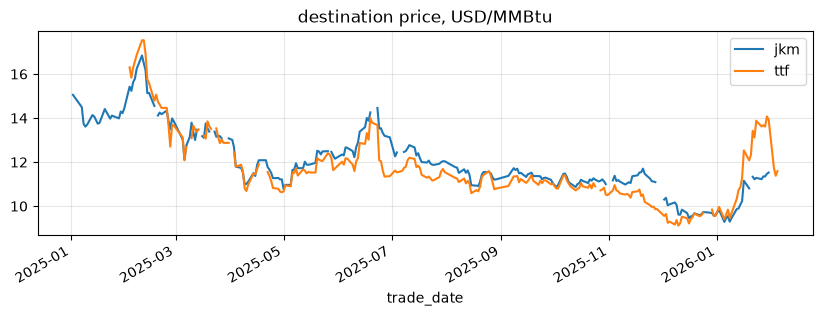

In [46]:
pd.DataFrame({"jkm": tokyo["dest_settle"], "ttf": ttf_usd}).plot(title="destination price, USD/MMBtu");

In [47]:
# freight: a round-trip day rate, over the days on hire, spread over the cargo
days = {route: r["laden_days"] * c.ROUND_TRIP + c.PORT_DAYS for route, r in c.ROUTES.items()}
days

{'tokyo': 42, 'rotterdam': 22}

In [48]:
pd.DataFrame({"blng3_usd_day": tokyo["freight_settle"],
              "freight_usd_mmbtu": tokyo["freight_settle"] * days["tokyo"] / c.CARGO_MMBTU}).tail(3)

,blng3_usd_day,freight_usd_mmbtu
trade_date,,
2026-01-28,"42,250.000",0.507
2026-01-29,"42,250.000",0.507
2026-01-30,"42,250.000",0.507


In [49]:
# boil-off compounds on what is left: the share of the cargo that arrives
{route: round((1 - c.BOIL_OFF_PER_DAY) ** r["laden_days"], 4) for route, r in c.ROUTES.items()}

{'tokyo': 0.9704, 'rotterdam': 0.9851}

In [50]:
# the lump sums a Baltic rate does not carry, per loaded MMBtu
{route: {"canal": round(r["canal_usd"] / c.CARGO_MMBTU, 3), "port": round(c.PORT_COST_USD / c.CARGO_MMBTU, 3),
         "regas": r["regas_usd_mmbtu"]} for route, r in c.ROUTES.items()}

{'tokyo': {'canal': 0.286, 'port': 0.057, 'regas': 0.0},
 'rotterdam': {'canal': 0.0, 'port': 0.057, 'regas': 0.5}}

In [51]:
# the stack netback.py builds from these, every column USD/MMBtu
netback.netback("tokyo", tokyo).tail(3)

,dest_price,boiloff,regas,freight,canal,port,netback
trade_date,,,,,,,
2026-01-28,11.350,0.336,0.000,0.507,0.286,0.057,10.164
2026-01-29,11.465,0.339,0.000,0.507,0.286,0.057,10.276
2026-01-30,11.525,0.341,0.000,0.507,0.286,0.057,10.334


In [52]:
netback.netback("rotterdam", rotterdam).tail(3)

,dest_price,boiloff,regas,freight,canal,port,netback
trade_date,,,,,,,
2026-02-02,11.728,0.175,0.493,0.091,0.000,0.057,10.912
2026-02-03,11.379,0.170,0.493,0.091,0.000,0.057,10.569
2026-02-04,11.591,0.173,0.493,0.091,0.000,0.057,10.777


## Final checks

In [53]:
tokyo.shape, rotterdam.shape

((257, 10), (242, 13))

In [54]:
tokyo.index.min(), tokyo.index.max(), rotterdam.index.min(), rotterdam.index.max()

(Timestamp('2025-01-02 00:00:00'),
 Timestamp('2026-01-30 00:00:00'),
 Timestamp('2025-02-03 00:00:00'),
 Timestamp('2026-02-04 00:00:00'))

In [55]:
tokyo.describe(include="number").round(3).T

,count,mean,std,min,25%,50%,75%,max
dest_settle,257.000,12.042,1.500,9.285,11.150,11.660,13.085,16.840
freight_settle,257.000,"43,491.661","14,696.041","19,000.000","35,250.000","43,667.000","48,125.000","109,500.000"
staleness_days,257.000,0.004,0.062,0.000,0.000,0.000,0.000,1.000


In [56]:
rotterdam.describe(include="number").round(3).T

,count,mean,std,min,25%,50%,75%,max
dest_settle,242.000,35.099,6.013,26.602,31.804,33.275,36.670,58.039
freight_settle,242.000,"35,000.698","21,451.923","4,333.000","23,375.000","34,750.000","40,000.000","130,000.000"
eurusd,242.000,1.142,0.041,1.031,1.131,1.160,1.170,1.204
staleness_days,242.000,1.219,0.636,1.000,1.000,1.000,1.000,4.000


Dataset ready for the netback.